# 02 — Audio Inspection

Run this notebook once. It automatically obtains GTZAN if it is not already in Google Drive, creates the shared song-level split manifest, verifies leakage, and inspects audio.


In [8]:
!pip -q install librosa soundfile scikit-learn tqdm


In [9]:
from pathlib import Path

PROJECT_ROOT = Path("/content/music-genre-classification")

DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
GENRES_ROOT = RAW_ROOT / "genres"
MANIFEST_PATH = DATA_ROOT / "split_manifest.csv"

print("Project:", PROJECT_ROOT)
print("Audio:", GENRES_ROOT)
print("Manifest:", MANIFEST_PATH)

Project: /content/music-genre-classification
Audio: /content/music-genre-classification/data/raw/genres
Manifest: /content/music-genre-classification/data/split_manifest.csv


In [10]:
import requests, tarfile, zipfile, shutil

ARCHIVE_PATH = Path("/content/gtzan_raw_dataset")
GTZAN_URL = (
    "https://ibm.ent.box.com/index.php"
    "?rm=box_download_shared_file"
    "&shared_name=gvkgmb4n0h6rbeccdwtwa0ujjjfmouof"
    "&file_id=f_961929491012"
)

audio = list(GENRES_ROOT.rglob("*.au")) + list(GENRES_ROOT.rglob("*.wav"))

if len(audio) >= 1000:
    print("GTZAN already exists in Drive:", len(audio), "files")
else:
    print("Downloading GTZAN automatically...")
    r = requests.get(GTZAN_URL, stream=True, allow_redirects=True, timeout=120)
    r.raise_for_status()
    with open(ARCHIVE_PATH, "wb") as f:
        for chunk in r.iter_content(1024 * 1024):
            if chunk:
                f.write(chunk)
    print("Downloaded:", round(ARCHIVE_PATH.stat().st_size / 1024**2, 2), "MB")

    if tarfile.is_tarfile(ARCHIVE_PATH):
        with tarfile.open(ARCHIVE_PATH, "r:*") as t:
            t.extractall(RAW_ROOT)
    elif zipfile.is_zipfile(ARCHIVE_PATH):
        with zipfile.ZipFile(ARCHIVE_PATH) as z:
            z.extractall(RAW_ROOT)
    else:
        raise RuntimeError("Unsupported archive format")

    # Normalize an extracted nested genres folder.
    candidates = list(RAW_ROOT.rglob("genres"))
    if not GENRES_ROOT.exists() or len(list(GENRES_ROOT.rglob("*.au"))) + len(list(GENRES_ROOT.rglob("*.wav"))) < 1000:
        if candidates:
            src = max(candidates, key=lambda p: len(list(p.rglob("*"))))
            GENRES_ROOT.mkdir(parents=True, exist_ok=True)
            for item in src.iterdir():
                dst = GENRES_ROOT / item.name
                if not dst.exists():
                    shutil.move(str(item), str(dst))

audio = list(GENRES_ROOT.rglob("*.au")) + list(GENRES_ROOT.rglob("*.wav"))
print("Total audio files:", len(audio))
assert len(audio) == 1000


GTZAN already exists in Drive: 1000 files
Total audio files: 1000


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)
    print("Existing manifest loaded.")
else:
    rows = []
    for gdir in sorted(GENRES_ROOT.iterdir()):
        if gdir.is_dir():
            for p in sorted(list(gdir.glob("*.au")) + list(gdir.glob("*.wav"))):
                rows.append({"relative_path": str(p.relative_to(RAW_ROOT)), "genre": gdir.name})

    base = pd.DataFrame(rows)
    parts = []
    for genre in sorted(base.genre.unique()):
        g = base[base.genre == genre]
        train, temp = train_test_split(g, test_size=.30, random_state=42)
        val, test = train_test_split(temp, test_size=.50, random_state=42)
        train["split"], val["split"], test["split"] = "train", "validation", "test"
        parts += [train, val, test]

    manifest = pd.concat(parts, ignore_index=True)[["relative_path","genre","split"]]
    manifest.to_csv(MANIFEST_PATH, index=False)
    print("Created manifest.")

print(manifest.shape)
print(manifest.split.value_counts())
print(pd.crosstab(manifest.genre, manifest.split))


Existing manifest loaded.
(1000, 3)
split
train         700
validation    150
test          150
Name: count, dtype: int64
split      test  train  validation
genre                             
blues        15     70          15
classical    15     70          15
country      15     70          15
disco        15     70          15
hiphop       15     70          15
jazz         15     70          15
metal        15     70          15
pop          15     70          15
reggae       15     70          15
rock         15     70          15


In [12]:
leakage = (manifest.groupby("relative_path").split.nunique() > 1).sum()
missing = [p for p in manifest.relative_path if not (RAW_ROOT / p).exists()]

print("Tracks in multiple splits:", leakage)
print("Missing paths:", len(missing))

assert len(manifest) == 1000
assert leakage == 0
assert len(missing) == 0
print("Song-level split verification PASSED.")


Tracks in multiple splits: 0
Missing paths: 0
Song-level split verification PASSED.


In [7]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

row = manifest.iloc[0]
path = RAW_ROOT / row.relative_path
y, sr = librosa.load(path, sr=None, mono=True)

print("Genre:", row.genre)
print("Split:", row.split)
print("Duration:", round(len(y)/sr, 2), "seconds")


Genre: blues
Split: train
Duration: 30.01 seconds


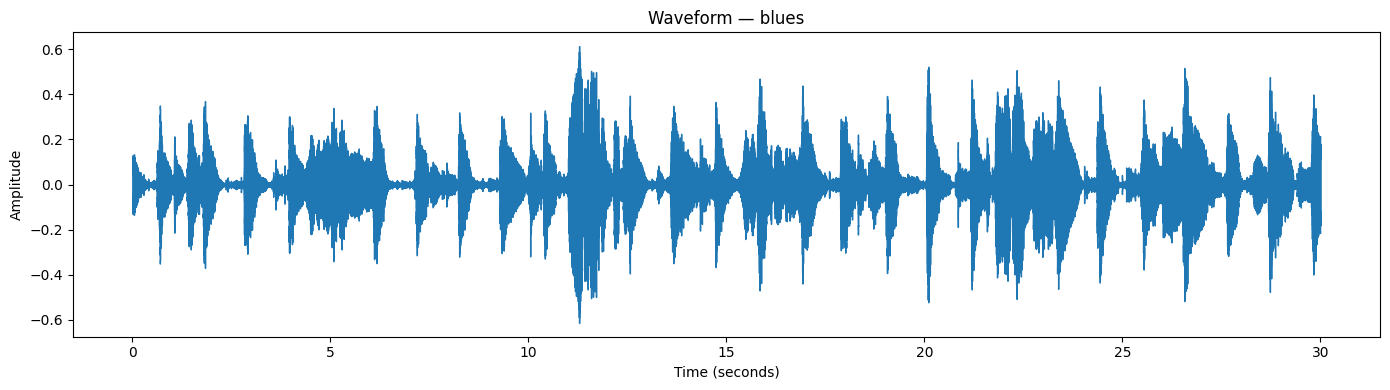

In [13]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform — {row.genre}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


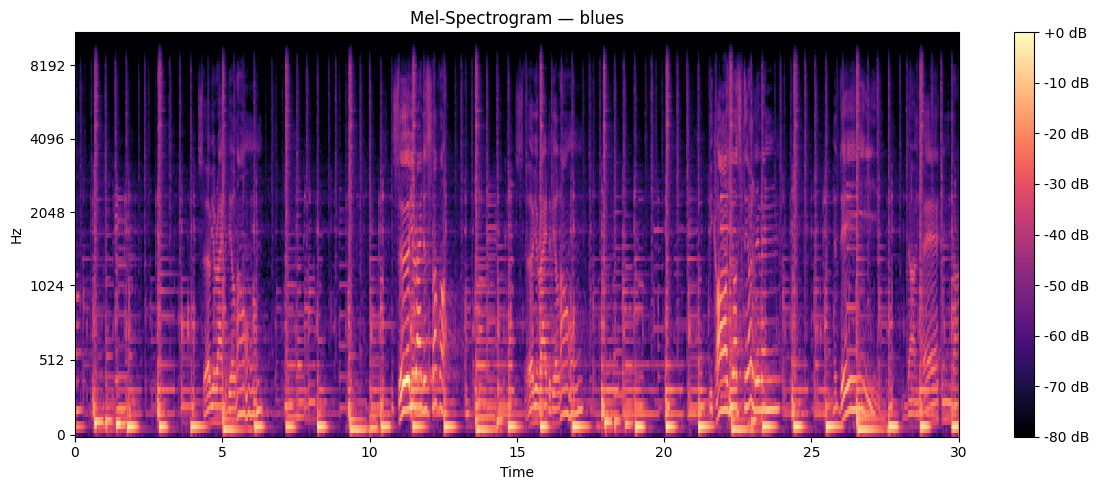

In [14]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=sr//2)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12,5))
librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel-Spectrogram — {row.genre}")
plt.tight_layout()
plt.show()


In [15]:
genres = sorted(manifest.genre.unique())
print("Genres:", genres)
print("Number of genres:", len(genres))


Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of genres: 10


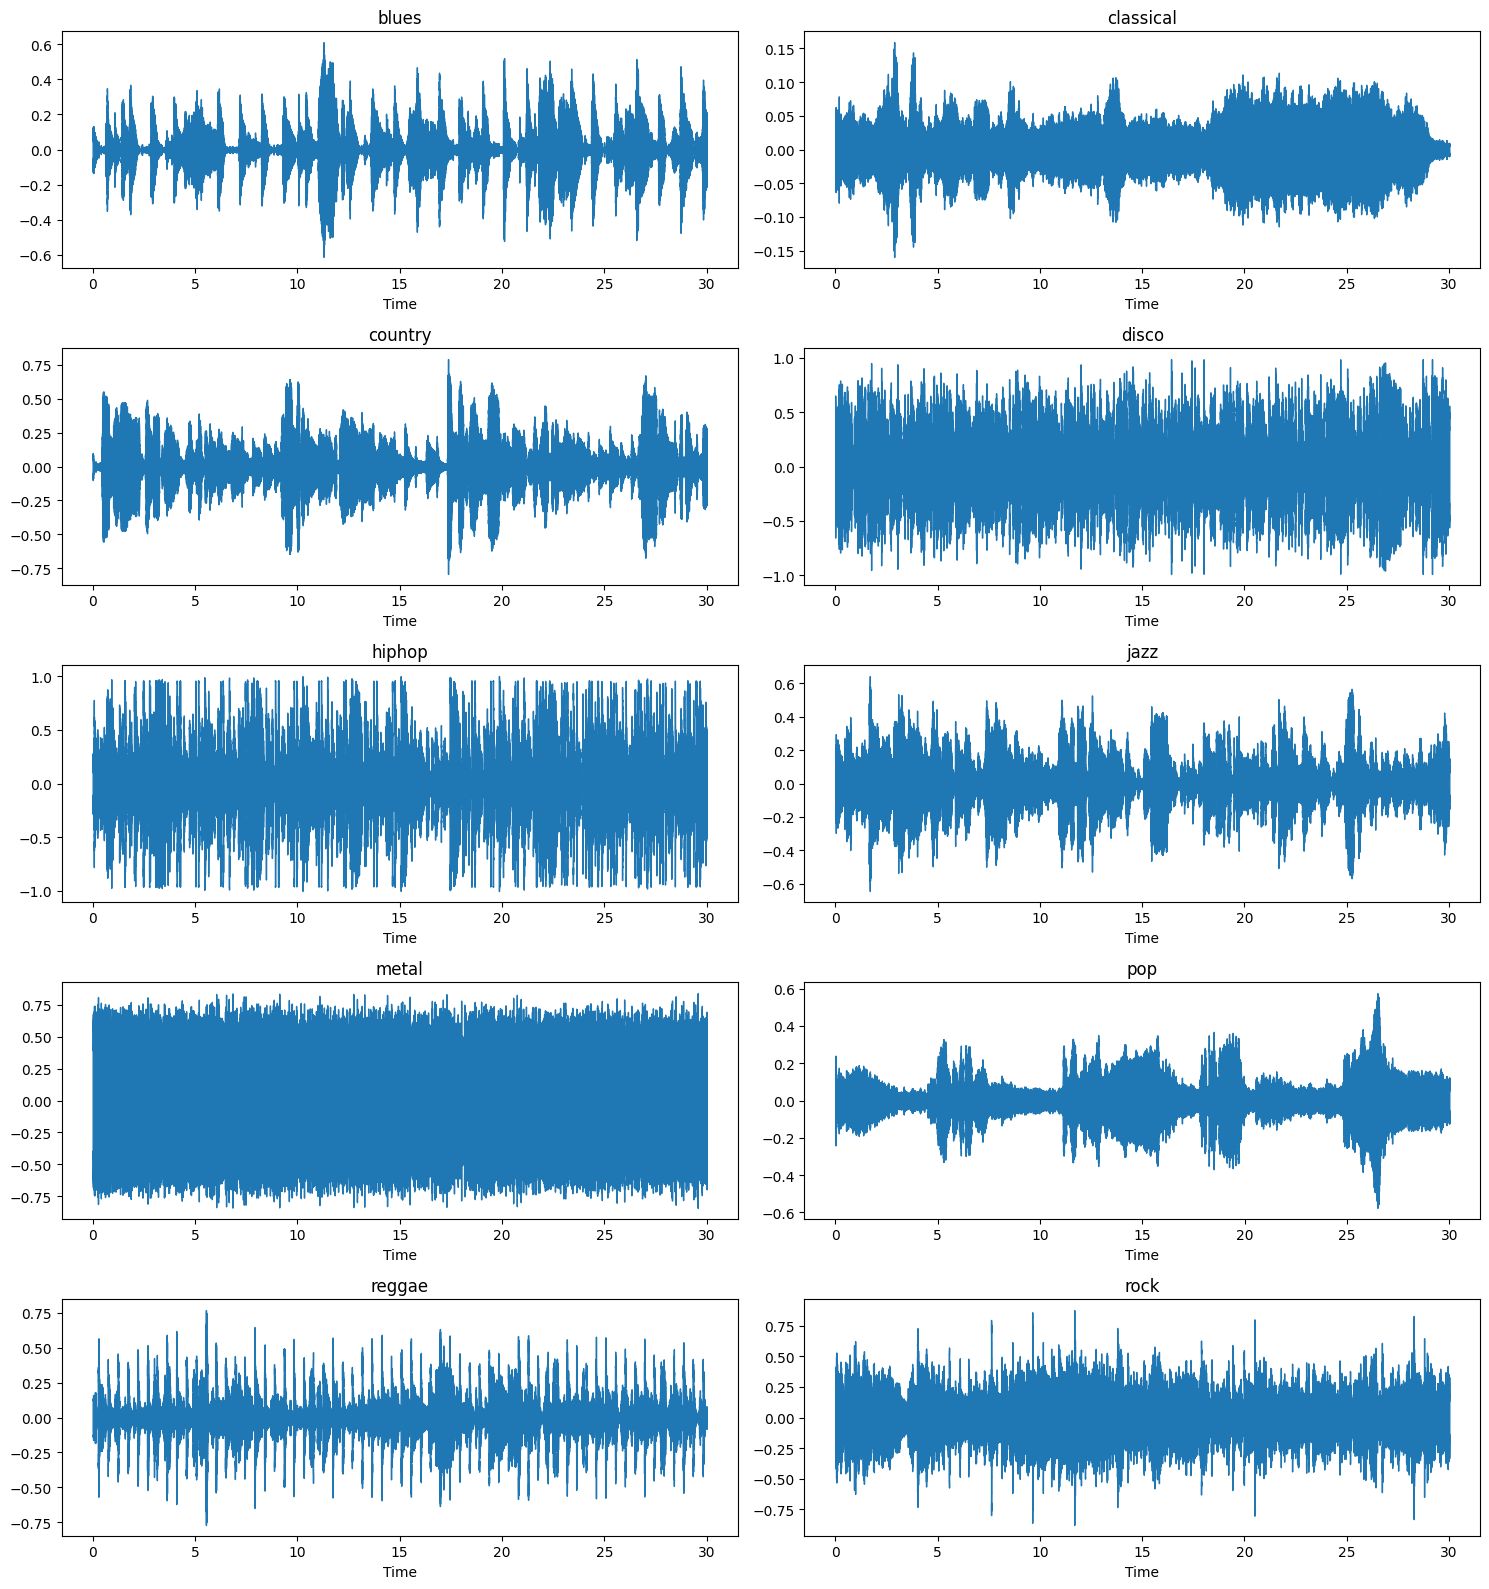

Notebook 02 completed.


In [16]:
fig, axes = plt.subplots(5, 2, figsize=(15,16))
for ax, genre in zip(axes.flat, genres):
    r = manifest[manifest.genre == genre].iloc[0]
    yy, ss = librosa.load(RAW_ROOT / r.relative_path, sr=None, mono=True)
    librosa.display.waveshow(yy, sr=ss, ax=ax)
    ax.set_title(genre)
plt.tight_layout()
plt.show()
print("Notebook 02 completed.")
